In [3]:
import logging
import sys
logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))
from cosipy.util import fetch_wasabi_file

# dependencies for response
import numpy as np
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic
from astropy.io import fits
from astropy.time import Time
from astropy.table import Table
import matplotlib.pyplot as plt

# dependencies for plotting mollweide projections
from mhealpy import HealpixMap, HealpixBase
import healpy as hp
import pandas as pd
from pathlib import Path

# This is cosi.response
from scoords import Attitude, SpacecraftFrame
from cosipy.response import FullDetectorResponse, DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data
from histpy import Histogram, HealpixAxis, Axis, Axes
import gc

# This is cosi.BinnedData
from cosipy import BinnedData, UnBinnedData
# this is for fitting and forward folding (#3ML is needed for spectral modeling)
from threeML import Model, Powerlaw
from astromodels import Band


# This is cosi_image_deconvolution
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix, DataIF_COSI_DC2, ImageDeconvolution
from cosipy.util import fetch_wasabi_file
from cosipy.ts_map.TSMap import TSMap

# dependencies for data handling
import shutil
import os
from hashlib import md5

/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/utils/file_utils.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


16:44:59 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=67263;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=454126;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#47\47]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=363871;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=847243;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#68\68]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=276571;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=484213;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=771090;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=306333;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

...

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=446103;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=509830;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=786493;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=998808;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=356933;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=628706;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=307638;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=393045;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=247708;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=982391;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [ ]:
def get_dict_from_hdf5(object, input_hdf5):

    this_dict = {}
    # Fill dictionary from input h5fy file:
    hf = h5py.File(input_hdf5,"r")
    keys = list(hf.keys())
    for each in keys:
        this_dict[each] = np.array(hf[each])

    return this_dict

In [1]:
response_path = "data/Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5"

In [4]:
ori = SpacecraftFile.parse_from_file("data/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori")


In [5]:
with FullDetectorResponse.open(response_path) as response:
    nside_local = response.nside
    npix_local = hp.nside2npix(nside_local)
    # psr = response.get_extended_source_response(orientation=ori)
    
nside_local, npix_local

(16, 3072)

In [6]:
response = FullDetectorResponse.open(response_path)
response

FILENAME: '/home/ricekong/cosipy/docs/tutorials/60Fe/testing/data/Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 3072
    NSIDE: 16
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [1329.0 keV, 1336.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [1329.0 keV, 1336.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 60
    EDGES: [0.0 deg, 3.0 deg, 6.0 deg, 9.0 deg, 12.0 deg, 15.0 deg, 18.0 deg, 21.0 deg, 24.0 deg, 27.0 deg, 30.0 deg, 33.0 deg, 36.0 deg, 39.0 deg, 42.0 deg, 45.0 deg, 48.0 deg, 51.0 deg, 54.0 deg, 57.0 deg, 60.0 deg, 63.0 deg, 66.0 deg, 69.0 deg, 72.0 deg, 75.0 deg, 78.0 deg, 81.0 deg, 84.0 

In [7]:
exposure_table = SpacecraftAttitudeExposureTable.from_orientation(ori, nside_local)

--- Logging error ---
Traceback (most recent call last):
  File "/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/logging/__init__.py", line 1100, in emit
    msg = self.format(record)
  File "/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/logging/__init__.py", line 943, in format
    return fmt.format(record)
  File "/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/logging/__init__.py", line 678, in format
    record.message = record.getMessage()
  File "/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/logging/__init__.py", line 368, in getMessage
    msg = msg % self.args
TypeError: not all arguments converted during string formatting
Call stack:
  File "/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/ricekong/mini

  0%|          | 0/531997 [00:00<?, ?it/s]

In [8]:
exposure_table

,scatt_binning_index,healpix_index,zpointing,xpointing,zpointing_averaged,xpointing_averaged,delta_time,exposure,num_pointings,bkg_group
0,0,"(2340, 182)","[[22.574117544763574, -31.110730874676822], [2...","[[22.574117544763574, 58.88926912532318], [22....","[22.531865983362074, -31.00790853492032]","[22.534830601784506, 58.99233544039963]","[15.000000000002345, 15.000000000002345, 15.00...",18630.0,1242,0
1,1,"(2340, 222)","[[22.890562060304546, -31.881626976766405], [2...","[[22.890562060304546, 58.1183730232336], [23.2...","[23.258256982901614, -32.7823975777024]","[23.263880268626757, 57.2180802358068]","[14.999999999992752, 15.000000000002345, 15.00...",26010.0,1734,0
2,2,"(2340, 267)","[[23.840879977830582, -34.19868307024379], [23...","[[23.84087997783058, 55.80131692975622], [23.7...","[23.77880720067148, -34.04202634110878]","[23.779032574521636, 55.95800335215191]","[15.000000000002345, 15.000000000002345, 14.99...",5655.0,377,0
3,3,"(2404, 267)","[[24.158420899721513, -34.97241501346041], [24...","[[24.158420899721506, 55.027584986539594], [24...","[24.449149312358237, -35.6831019120271]","[24.459250728663985, 54.3178648092337]","[14.999999999992752, 15.000000000002345, 15.00...",35490.0,2366,0
4,4,"(2404, 315)","[[25.11519953479184, -37.297431342520845], [25...","[[25.115199534791838, 52.70256865747916], [25....","[25.301677686085025, -37.75081792048012]","[25.30377989506407, 52.24938569873169]","[15.000000000002345, 14.999999999992752, 15.00...",16230.0,1082,0
...,...,...,...,...,...,...,...,...,...,...
3091,3091,"(113, 899)","[[18.856258361961434, 64.17240568347188]]","[[198.8562583619614, 25.82759431652813]]","[18.85625836196143, 64.17240568347188]","[198.8562583619614, 25.827594316528135]",[15.000000000002345],15.0,1,0
3092,3092,"(484, 395)","[[24.366312246878625, 42.187500311034995]]","[[204.36631224687858, 47.812499688965005]]","[24.366312246878625, 42.187500311034995]","[204.36631224687858, 47.81249968896501]",[15.000000000002345],15.0,1,0
3093,3093,"(548, 395)","[[23.19419869123921, 40.821622250446495]]","[[203.1941986912392, 49.17837774955349]]","[23.194198691239215, 40.821622250446495]","[203.1941986912392, 49.1783777495535]",[15.000000000002345],15.0,1,0
3094,3094,"(675, 201)","[[15.800124514097567, 31.086159136641342]]","[[195.80012451409755, 58.913840863358665]]","[15.800124514097567, 31.086159136641342]","[195.80012451409755, 58.91384086335866]",[15.000000000002345],15.0,1,0


In [9]:
exposure_table.save_as_fits("exposure_table_dc2.fits", overwrite = True)

In [10]:
map_pointing_zx = exposure_table.calc_pointing_trajectory_map()
map_pointing_zx = map_pointing_zx.to_dense()

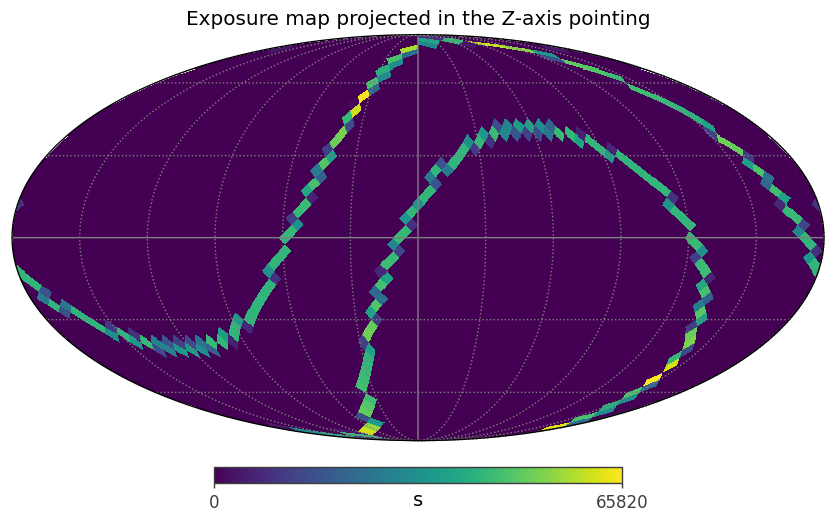

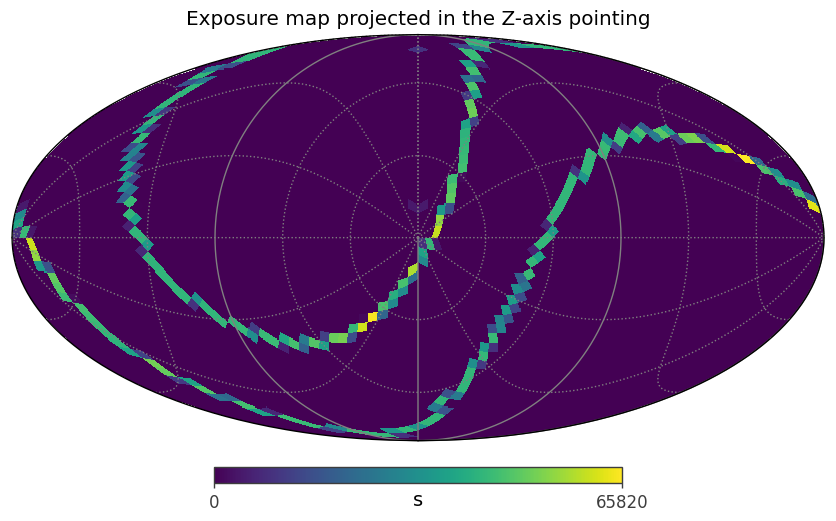

In [11]:
hp.mollview(map_pointing_zx.project('z').contents, rot=(0,0), unit = u.s, title = "Exposure map projected in the Z-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

hp.mollview(map_pointing_zx.project('z').contents, rot=(0,90), unit = u.s, title = "Exposure map projected in the Z-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

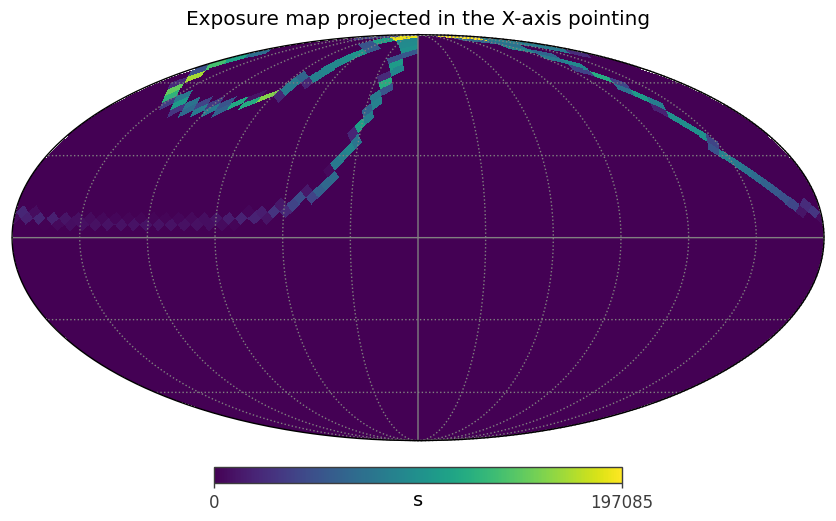

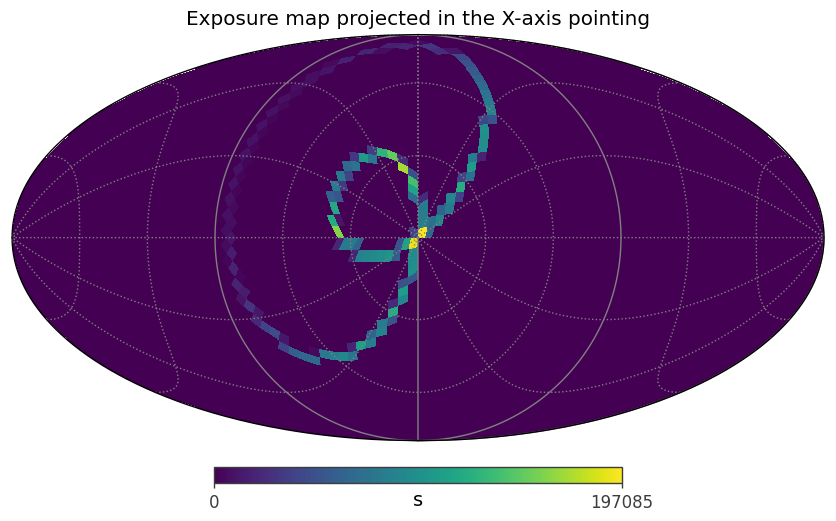

In [12]:
hp.mollview(map_pointing_zx.project('x').contents, rot=(0,0), unit = u.s, title = "Exposure map projected in the X-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

hp.mollview(map_pointing_zx.project('x').contents, rot=(0,90), unit = u.s, title = "Exposure map projected in the X-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

In [20]:

%%time

nside_model = nside_local
binned_event = Histogram.open("data/Fe60_galactic_event.hdf5")

time_int = binned_event.axes['Time'].edges
coordsys_conv_matrix = CoordsysConversionMatrix.time_binning_ccm(full_detector_response=response, orientation=ori, time_intervals=time_int, nside_model=nside_local)

  0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 6min 8s, sys: 40.2 s, total: 6min 49s
Wall time: 6min 49s


In [50]:
coordsys_conv_matrix.write("ccm_Fe60_timebinning.hdf5", overwrite = True)

In [52]:
ccm = CoordsysConversionMatrix.open("ccm_Fe60_timebinning.hdf5")